In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from tqdm import tqdm
from typing import Union

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
data = pd.read_csv("../powerconsumption.csv")
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")

series = data["PowerConsumption_Zone1"].dropna()
print(f"Shape: {series.shape}")
print(f"Period: {series.index.min()} → {series.index.max()}")

Shape: (52416,)
Period: 2017-01-01 00:00:00 → 2017-12-30 23:50:00


In [4]:
TESTTIMESTEPS  = 1008        #1 week = 7 × 144
SEASONAL_M = 144         #daily cycle in 10 minutes data
TRAIN_WINDOW = 90 * 144    #90 days for the SARIMA fit (12,960)

train_full = series.iloc[:-TESTTIMESTEPS]
test = series.iloc[-TESTTIMESTEPS:]

train = train_full.iloc[-TRAIN_WINDOW:]

print(f"Train (full): {len(train_full):,} obs  ({len(train_full)/SEASONAL_M:.0f} days)")
print(f"Train (SARIMA): {len(train):,} obs  ({len(train)/SEASONAL_M:.0f} days)")
print(f"Test: {len(test):,} obs  ({len(test)/SEASONAL_M:.0f} days)")
print(f"\nSARIMA train range: {train.index.min()} → {train.index.max()}")
print(f"Test range: {test.index.min()} → {test.index.max()}")

Train (full): 51,408 obs  (357 days)
Train (SARIMA): 12,960 obs  (90 days)
Test: 1,008 obs  (7 days)

SARIMA train range: 2017-09-25 00:00:00 → 2017-12-23 23:50:00
Test range: 2017-12-24 00:00:00 → 2017-12-30 23:50:00


Seasonality

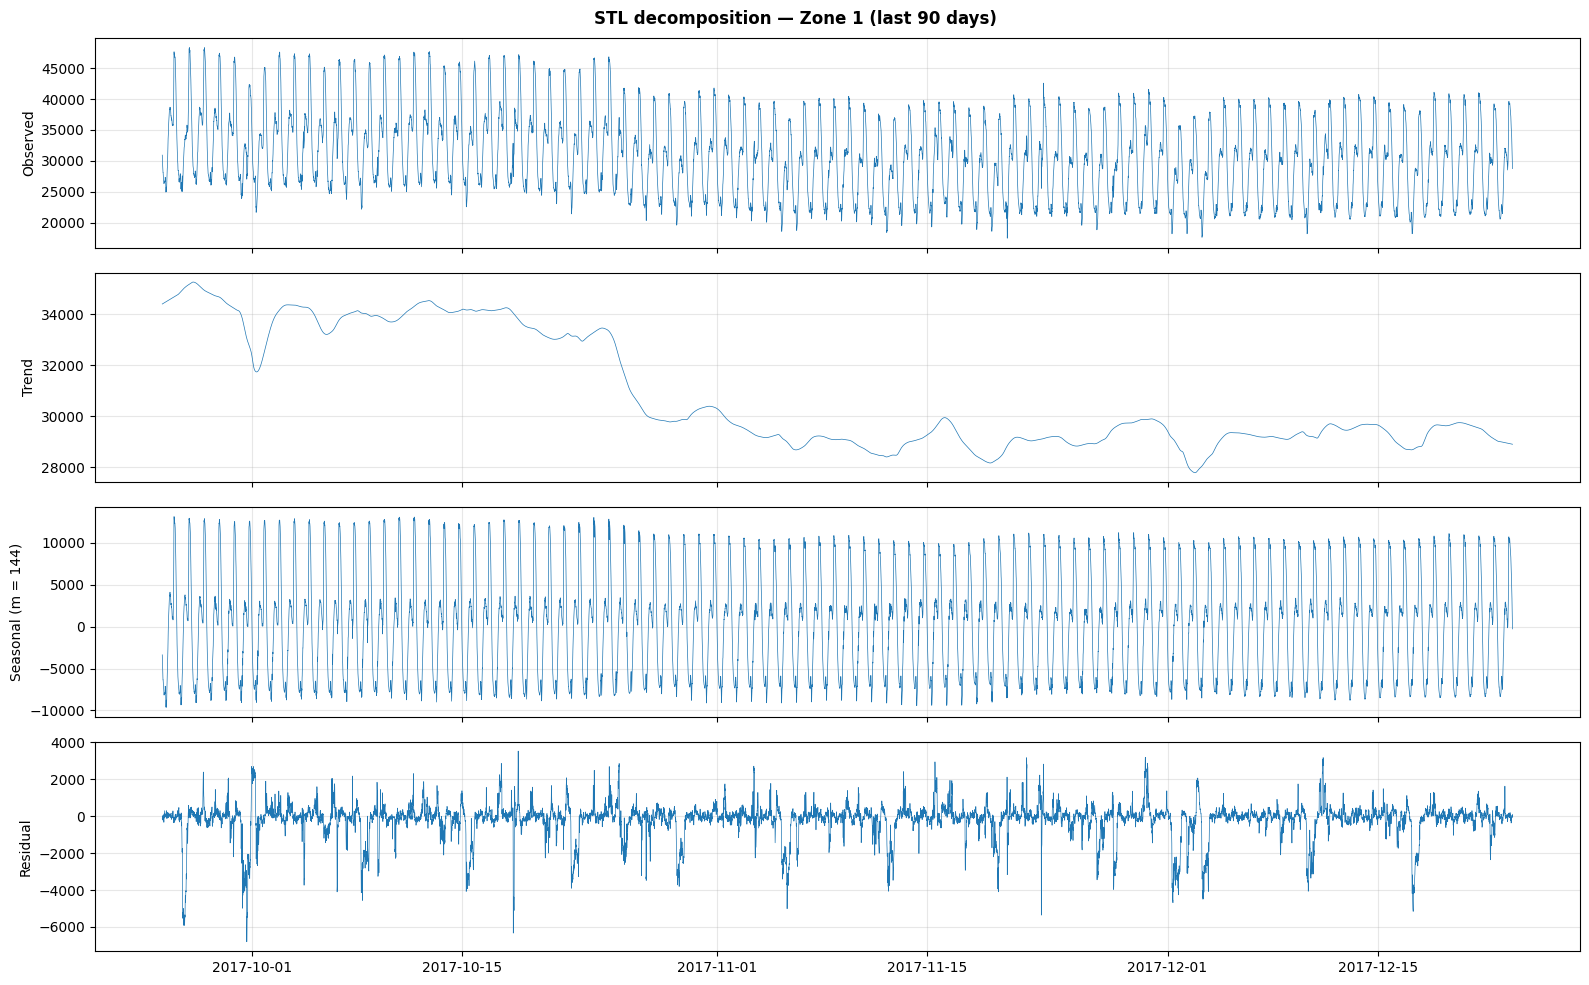

In [5]:
stl = STL(train, period=SEASONAL_M, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
for ax, (comp, title) in zip(axes, [
    (stl.observed, "Observed"),
    (stl.trend, "Trend"),
    (stl.seasonal, "Seasonal (m = 144)"),
    (stl.resid, "Residual"),
]):
    ax.plot(comp, linewidth=0.5)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
fig.suptitle("STL decomposition — Zone 1 (last 90 days)", fontweight="bold")
plt.tight_layout()
plt.show()

Stationarity

In [9]:
def adf_print(s, label):
    res = adfuller(s.dropna())
    print(f"{label:45s} ADF = {res[0]:8.3f} p-value = {res[1]:.4f}")

adf_print(train, "Raw")
adf_print(train.diff(), "After d = 1")
adf_print(train.diff().diff(SEASONAL_M), "After d = 1 and seasonal D = 1 (m = 144)")

Raw                                           ADF =  -17.305 p-value = 0.0000
After d = 1                                   ADF =  -18.064 p-value = 0.0000
After d = 1 and seasonal D = 1 (m = 144)      ADF =  -23.585 p-value = 0.0000


Grid Search

In [ ]:
import warnings
warnings.filterwarnings("ignore")
def optimize_SARIMA(endog, p_r, q_r, P_r, Q_r, d, D, m) -> pd.DataFrame:
    rows = []
    combos = list(product(p_r, q_r, P_r, Q_r))
    for p, q, P, Q in tqdm(combos):
        try:
            res = SARIMAX(endog,
                          order=(p, d, q),
                          seasonal_order=(P, D, Q, m),
                          simple_differencing=False,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            rows.append([(p, d, q, P, D, Q, m), res.aic])
        except Exception:
            continue
    return (pd.DataFrame(rows, columns=["order", "AIC"])
              .sort_values("AIC")
              .reset_index(drop=True))


D_REG, D_SEAS = 1, 1

grid = optimize_SARIMA(train,
                       p_r=range(0, 3), q_r=range(0, 3),
                       P_r=range(0, 2), Q_r=range(0, 2),
                       d=D_REG, D=D_SEAS, m=SEASONAL_M)
grid.head(10)

  3%|▎         | 1/36 [12:35<7:20:48, 755.67s/it]

In [ ]:
import warnings
warnings.filterwarnings("ignore")
def optimize_SARIMA(endog, p_r, q_r, P_r, Q_r, d, D, m) -> pd.DataFrame:
    rows = []
    combos = list(product(p_r, q_r, P_r, Q_r))
    for p, q, P, Q in tqdm(combos):
        try:
            res = SARIMAX(endog,
                          order=(p, d, q),
                          seasonal_order=(P, D, Q, m),
                          simple_differencing=False,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            rows.append([(p, d, q, P, D, Q, m), res.aic])
        except Exception:
            continue
    return (pd.DataFrame(rows, columns=["order", "AIC"])
              .sort_values("AIC")
              .reset_index(drop=True))


D_REG, D_SEAS = 0, 1

grid = optimize_SARIMA(train,
                       p_r=range(0, 3), q_r=range(0, 3),
                       P_r=range(0, 2), Q_r=range(0, 2),
                       d=D_REG, D=D_SEAS, m=SEASONAL_M)
grid.head(10)